# WEC Power Estimation: Leixões Sea-State Characterization and Generic Power Matrix

This notebook uses the processed Leixões buoy sea-state table prepared in [Notebook 01](01_wave_data_preparation.ipynb).

The goal is to explore the available wave-height, period, direction, and extreme-wave variables before converting the sea-state record into a simplified estimated WEC electrical power signal.

The notebook is organized in three phases:

1. **Site characterization** — visualize the observed wave conditions and directionality.
2. **Sea-state consistency and operating-condition checks** — compare related height and period variables and define simple flags for interpretation.
3. **Simplified WEC electrical power estimation** — use a generic power-matrix-style approach to estimate an illustrative WEC power-output signal.

The estimated WEC power signal is intended for later forecasting, uncertainty, and storage-smoothing examples. It is not a validated device model or detailed WEC hydrodynamic simulation.


## Phase 1 — Site characterization

This phase gives a first visual overview of the Leixões buoy sea-state record prepared in [Notebook 01](01_wave_data_preparation.ipynb).

We start with the two main variables that will later drive the simplified WEC power estimate:

- `hm0_m`: spectral significant wave height
- `tp_s`: peak wave period

Missing values are kept as gaps in the plots.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mhkit.wave import graphics as wave_graphics

# Paths
PROCESSED_DATA_PATH = Path("../data/processed/leixoes_wave_30min_processed.parquet")
FIGURE_DIR = Path("../outputs/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load processed sea-state table from Notebook 01
wave_df = pd.read_parquet(PROCESSED_DATA_PATH)

wave_df["time"] = pd.to_datetime(wave_df["time"])
wave_df = wave_df.sort_values("time").reset_index(drop=True)

### Time series overview of wave height and peak period

This plot shows how significant wave height and peak period vary through the available February–June 2025 record.

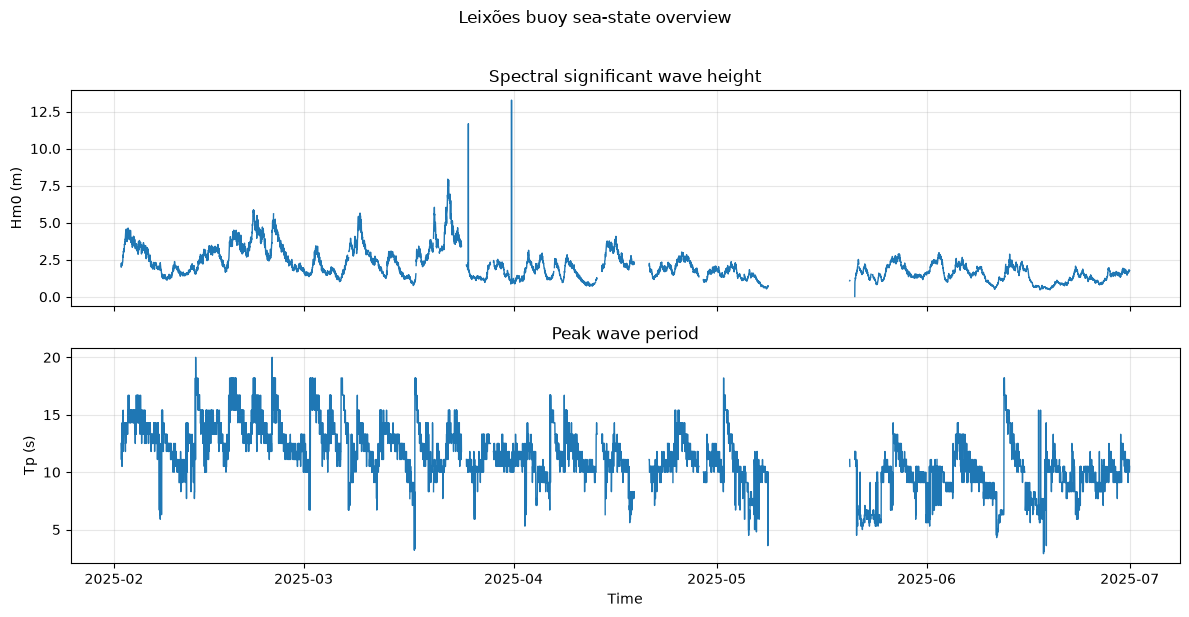

In [3]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 6),
    sharex=True,
)

axes[0].plot(wave_df["time"], wave_df["hm0_m"], linewidth=1.0)
axes[0].set_ylabel("Hm0 (m)")
axes[0].set_title("Spectral significant wave height")

axes[1].plot(wave_df["time"], wave_df["tp_s"], linewidth=1.0)
axes[1].set_ylabel("Tp (s)")
axes[1].set_xlabel("Time")
axes[1].set_title("Peak wave period")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.suptitle("Leixões buoy sea-state overview", y=1.02)
fig.tight_layout()

plt.show()

### Sea-state cloud: wave height versus peak period

The simplified WEC power estimate will mainly depend on wave height and wave period.  
This scatter plot shows the observed `hm0_m`–`tp_s` combinations in the Leixões record.

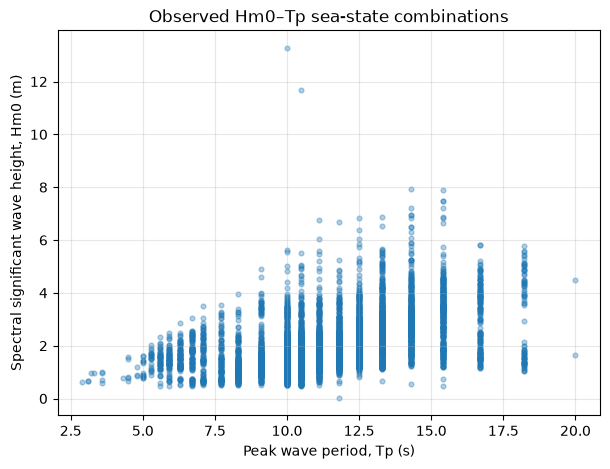

In [5]:
sea_state_df = wave_df.dropna(subset=["hm0_m", "tp_s"]).copy()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    sea_state_df["tp_s"],
    sea_state_df["hm0_m"],
    s=12,
    alpha=0.35,
)

ax.set_xlabel("Peak wave period, Tp (s)")
ax.set_ylabel("Spectral significant wave height, Hm0 (m)")
ax.set_title("Observed Hm0–Tp sea-state combinations")
ax.grid(True, alpha=0.3)

plt.show()

Most observed sea states are concentrated between about 5–17 s peak period and below roughly 5 m significant wave height. A few much larger wave-height values appear as energetic events or possible extremes in the record.

### Wave direction and directional spreading

Wave direction helps describe where the observed waves mainly come from.  
Here, a wave rose summarizes peak wave direction together with significant wave-height classes.

Directional spreading is shown separately because it describes how concentrated or broad the wave field is around the peak direction.

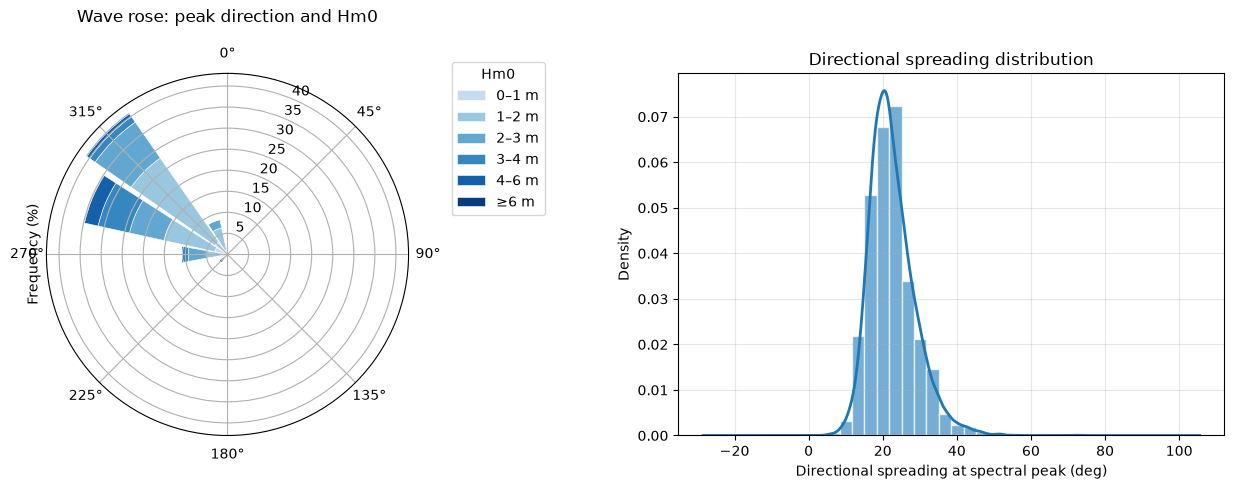

In [11]:
direction_df = wave_df.dropna(subset=["dir_peak_deg", "hm0_m"]).copy()
spread_df = wave_df.dropna(subset=["spread_peak_deg"]).copy()

# Direction is circular, so keep values in [0, 360).
direction_df["dir_peak_deg"] = direction_df["dir_peak_deg"] % 360

# Direction sectors for the rose plot.
sector_width_deg = 22.5
direction_centers = np.arange(0, 360, sector_width_deg)

direction_bin_idx = np.floor(
    ((direction_df["dir_peak_deg"] + sector_width_deg / 2) % 360) / sector_width_deg
).astype(int)

direction_df["direction_bin_deg"] = direction_bin_idx * sector_width_deg

# Wave-height classes.
hm0_bins = [0, 1, 2, 3, 4, 6, np.inf]
hm0_labels = ["0–1 m", "1–2 m", "2–3 m", "3–4 m", "4–6 m", "≥6 m"]

direction_df["hm0_class"] = pd.cut(
    direction_df["hm0_m"],
    bins=hm0_bins,
    labels=hm0_labels,
    right=False,
)

rose_counts = pd.crosstab(
    direction_df["direction_bin_deg"],
    direction_df["hm0_class"],
)

rose_counts = rose_counts.reindex(
    index=direction_centers,
    columns=hm0_labels,
    fill_value=0,
)

rose_freq = 100 * rose_counts / rose_counts.values.sum()

# Light-to-dark blue colors for increasing Hm0 classes.
hm0_colors = plt.cm.Blues(np.linspace(0.25, 0.95, len(hm0_labels)))

fig = plt.figure(figsize=(13, 5))

# Wave rose
ax1 = fig.add_subplot(1, 2, 1, projection="polar")

theta = np.deg2rad(direction_centers)
bar_width = np.deg2rad(sector_width_deg * 0.9)
bottom = np.zeros(len(direction_centers))

for hm0_class, color in zip(hm0_labels, hm0_colors):
    values = rose_freq[hm0_class].values
    ax1.bar(
        theta,
        values,
        width=bar_width,
        bottom=bottom,
        label=hm0_class,
        color=color,
        edgecolor="white",
        linewidth=0.4,
    )
    bottom += values

ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_title("Wave rose: peak direction and Hm0", pad=18)
ax1.set_ylabel("Frequency (%)")
ax1.legend(title="Hm0", bbox_to_anchor=(1.10, 1.05), loc="upper left")

# Directional spreading histogram + density curve
ax2 = fig.add_subplot(1, 2, 2)

spread_values = spread_df["spread_peak_deg"].dropna()

ax2.hist(
    spread_values,
    bins=20,
    density=True,
    color=plt.cm.Blues(0.65),
    edgecolor="white",
    alpha=0.7,
)

spread_values.plot.kde(ax=ax2, linewidth=2)

ax2.set_xlabel("Directional spreading at spectral peak (deg)")
ax2.set_ylabel("Density")
ax2.set_title("Directional spreading distribution")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

The wave rose shows that most recorded peak wave directions are concentrated around the northwest sector, with larger wave-height classes also appearing mainly from that direction. The spreading distribution is centred around roughly 20–30°, suggesting that many observed sea states have a fairly concentrated peak direction rather than very broad directional spreading.